In [333]:
## Customer churn prediction

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

from sklearn.ensemble import VotingClassifier

In [14]:
from sklearn.metrics import confusion_matrix, accuracy_score 
from sklearn.metrics import f1_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import classification_report, precision_recall_curve
from sklearn.metrics import auc, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score, log_loss
from sklearn.metrics import average_precision_score
#Standard libraries for data visualization:

In [16]:
data = pd.read_csv("/Users/mitho/Desktop/PT 1/Customer Churn prediction/Book1.csv")
data.head()

,customerID,age,gender,Contract,MonthlyCharges,TotalCharges,TechSupport,InternetService,tenure,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,26,Female,Month-to-month,29.85,29.85,No,DSL,1,Yes,Electronic check,No
1,5575-GNVDE,27,Male,One year,56.95,1889.5,No,DSL,34,No,Mailed check,No
2,3668-QPYBK,19,Male,Month-to-month,53.85,108.15,No,DSL,2,Yes,Mailed check,Yes
3,7795-CFOCW,27,Male,One year,42.30,1840.75,Yes,DSL,45,No,Bank transfer (automatic),No
4,9237-HQITU,22,Female,Month-to-month,70.70,151.65,No,Fiber optic,2,Yes,Electronic check,Yes


In [18]:
data.isnull().any().any()

False

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   age               7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   MonthlyCharges    7043 non-null   float64
 5   TotalCharges      7043 non-null   object 
 6   TechSupport       7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   tenure            7043 non-null   int64  
 9   PaperlessBilling  7043 non-null   object 
 10  PaymentMethod     7043 non-null   object 
 11  Churn             7043 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 660.4+ KB


In [15]:
data.shape

(7043, 12)

### Visualize missing values

<Axes: >

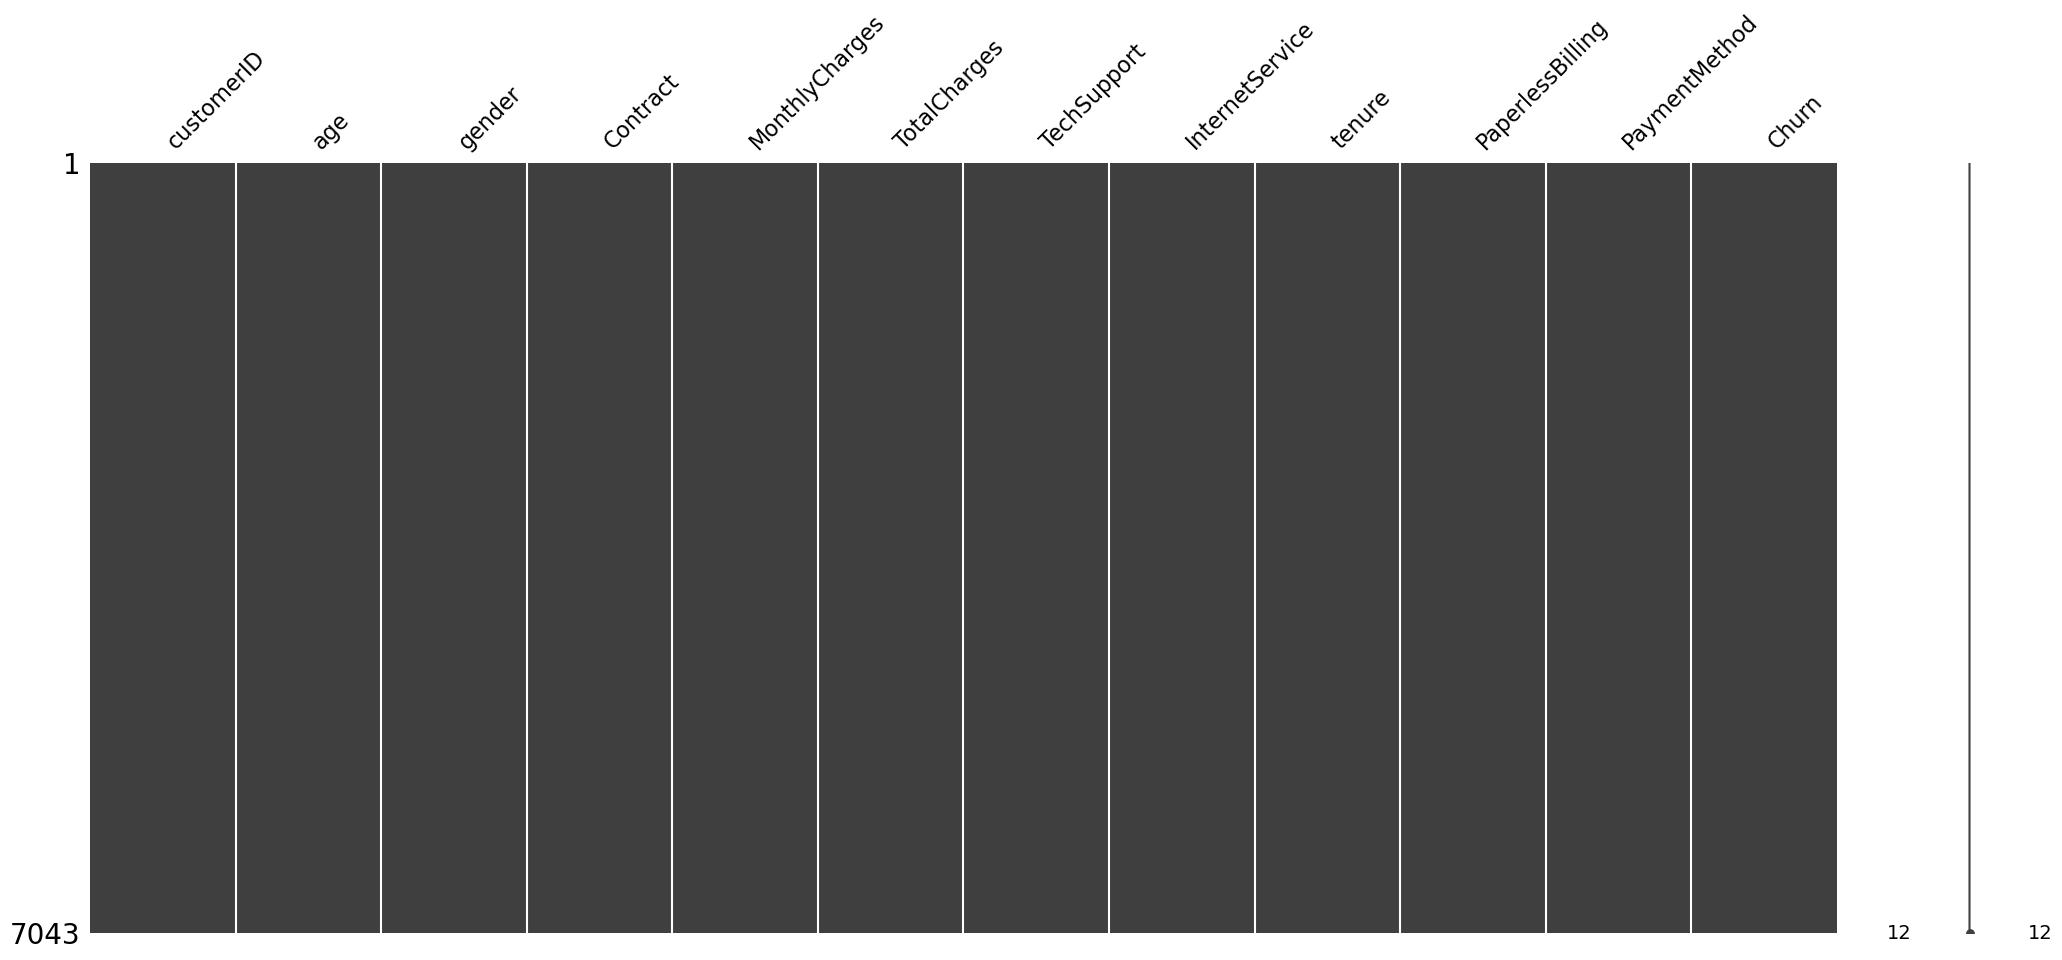

In [18]:
import missingno as msno
msno.matrix(data)


In [20]:
data = data.drop(["customerID"], axis = 1)
data.head()

,age,gender,Contract,MonthlyCharges,TotalCharges,TechSupport,InternetService,tenure,PaperlessBilling,PaymentMethod,Churn
0,26,Female,Month-to-month,29.85,29.85,No,DSL,1,Yes,Electronic check,No
1,27,Male,One year,56.95,1889.5,No,DSL,34,No,Mailed check,No
2,19,Male,Month-to-month,53.85,108.15,No,DSL,2,Yes,Mailed check,Yes
3,27,Male,One year,42.30,1840.75,Yes,DSL,45,No,Bank transfer (automatic),No
4,22,Female,Month-to-month,70.70,151.65,No,Fiber optic,2,Yes,Electronic check,Yes


In [22]:
data[data["TotalCharges"] == ' ']


,age,gender,Contract,MonthlyCharges,TotalCharges,TechSupport,InternetService,tenure,PaperlessBilling,PaymentMethod,Churn
488,27,Female,Two year,52.55,,Yes,DSL,0,Yes,Bank transfer (automatic),No
753,29,Male,Two year,20.25,,No internet service,No,0,No,Mailed check,No
936,25,Female,Two year,80.85,,No,DSL,0,No,Mailed check,No
1082,30,Male,Two year,25.75,,No internet service,No,0,No,Mailed check,No
1340,19,Female,Two year,56.05,,Yes,DSL,0,No,Credit card (automatic),No
3331,20,Male,Two year,19.85,,No internet service,No,0,No,Mailed check,No
3826,26,Male,Two year,25.35,,No internet service,No,0,No,Mailed check,No
4380,30,Female,Two year,20.00,,No internet service,No,0,No,Mailed check,No
5218,30,Male,One year,19.70,,No internet service,No,0,Yes,Mailed check,No
6670,26,Female,Two year,73.35,,Yes,DSL,0,No,Mailed check,No


In [24]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()

age                  0
gender               0
Contract             0
MonthlyCharges       0
TotalCharges        11
TechSupport          0
InternetService      0
tenure               0
PaperlessBilling     0
PaymentMethod        0
Churn                0
dtype: int64

### There are 11 records with missing Total charges

In [27]:
data[data["tenure"] == 0]

,age,gender,Contract,MonthlyCharges,TotalCharges,TechSupport,InternetService,tenure,PaperlessBilling,PaymentMethod,Churn
488,27,Female,Two year,52.55,NaN,Yes,DSL,0,Yes,Bank transfer (automatic),No
753,29,Male,Two year,20.25,NaN,No internet service,No,0,No,Mailed check,No
936,25,Female,Two year,80.85,NaN,No,DSL,0,No,Mailed check,No
1082,30,Male,Two year,25.75,NaN,No internet service,No,0,No,Mailed check,No
1340,19,Female,Two year,56.05,NaN,Yes,DSL,0,No,Credit card (automatic),No
3331,20,Male,Two year,19.85,NaN,No internet service,No,0,No,Mailed check,No
3826,26,Male,Two year,25.35,NaN,No internet service,No,0,No,Mailed check,No
4380,30,Female,Two year,20.00,NaN,No internet service,No,0,No,Mailed check,No
5218,30,Male,One year,19.70,NaN,No internet service,No,0,Yes,Mailed check,No
6670,26,Female,Two year,73.35,NaN,Yes,DSL,0,No,Mailed check,No


In [29]:
data.drop(labels=data[data["tenure"] == 0].index, axis = 0, inplace = True)

In [31]:
data.fillna(data["TotalCharges"].mean())


,age,gender,Contract,MonthlyCharges,TotalCharges,TechSupport,InternetService,tenure,PaperlessBilling,PaymentMethod,Churn
0,26,Female,Month-to-month,29.85,29.85,No,DSL,1,Yes,Electronic check,No
1,27,Male,One year,56.95,1889.50,No,DSL,34,No,Mailed check,No
2,19,Male,Month-to-month,53.85,108.15,No,DSL,2,Yes,Mailed check,Yes
3,27,Male,One year,42.30,1840.75,Yes,DSL,45,No,Bank transfer (automatic),No
4,22,Female,Month-to-month,70.70,151.65,No,Fiber optic,2,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...
7038,21,Male,One year,84.80,1990.50,Yes,DSL,24,Yes,Mailed check,No
7039,26,Female,One year,103.20,7362.90,No,Fiber optic,72,Yes,Credit card (automatic),No
7040,30,Female,Month-to-month,29.60,346.45,No,DSL,11,Yes,Electronic check,No
7041,22,Male,Month-to-month,74.40,306.60,No,Fiber optic,4,Yes,Mailed check,Yes


In [33]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()

age                 0
gender              0
Contract            0
MonthlyCharges      0
TotalCharges        0
TechSupport         0
InternetService     0
tenure              0
PaperlessBilling    0
PaymentMethod       0
Churn               0
dtype: int64

In [35]:
data.InternetService.describe(include=["object", "bool"])

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

## EDA

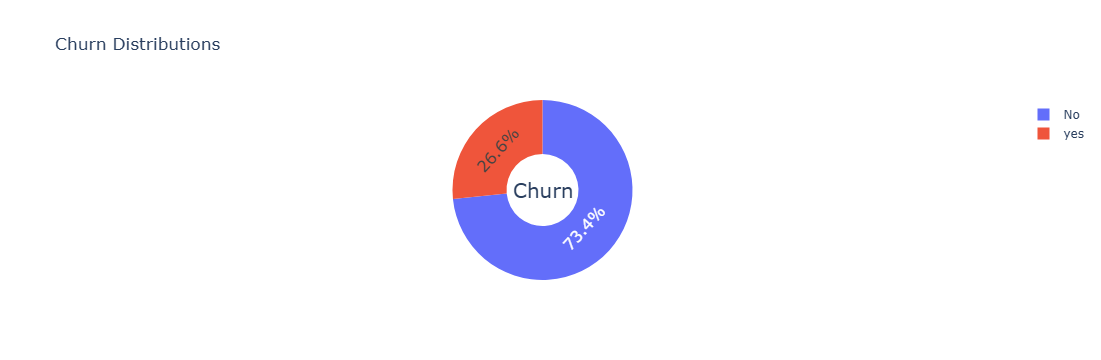

In [38]:
type_ = ["No", "yes"]
fig = make_subplots(rows=1, cols=1)

fig.add_trace(go.Pie(labels=type_, values=data['Churn'].value_counts(), name="Churn"))

# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Churn Distributions",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Churn', x=0.5, y=0.5, font_size=20, showarrow=False)])
fig.show()

In [40]:
data.Churn[data.Churn == "No"].groupby(by = data.gender).count()

gender
Female    2544
Male      2619
Name: Churn, dtype: int64

In [42]:
data.Churn[data.Churn == "Yes"].groupby(by = data.gender).count()

gender
Female    939
Male      930
Name: Churn, dtype: int64

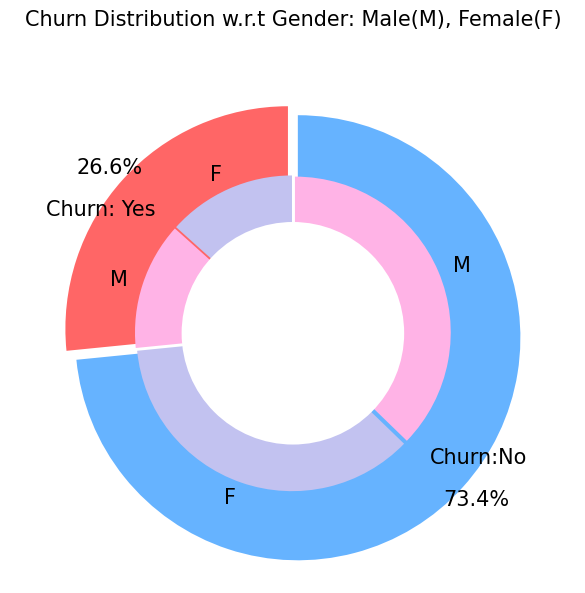

In [44]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["F","M","F","M"]
sizes_gender = [939,930 , 2544,2619]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3) 
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.1)

# show plot 
 
plt.axis('equal')
plt.tight_layout()
plt.show()

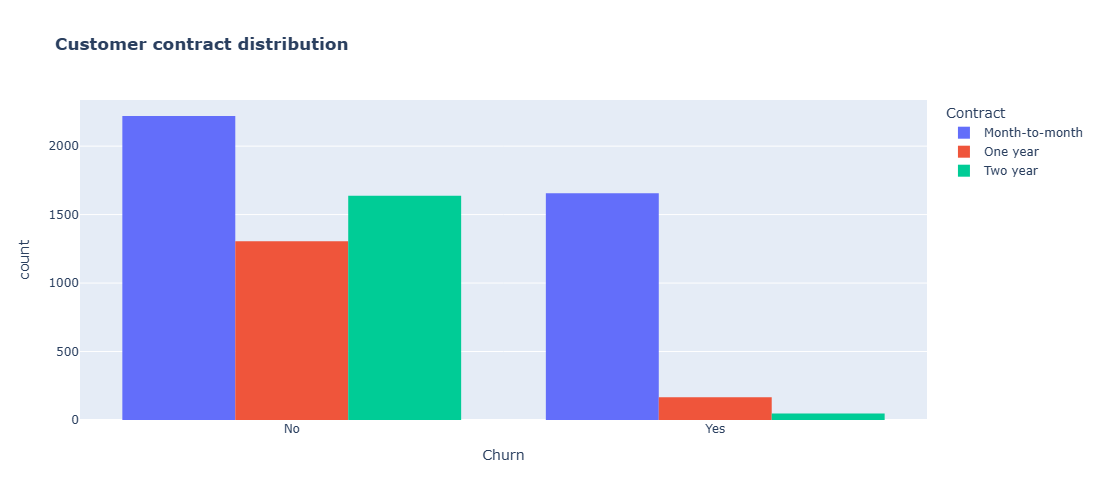

In [46]:
fig = px.histogram(data, x="Churn", color = "Contract", barmode = "group", title = "<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.2)
fig.show()

#### Customers with monthly contract are more likely to churn

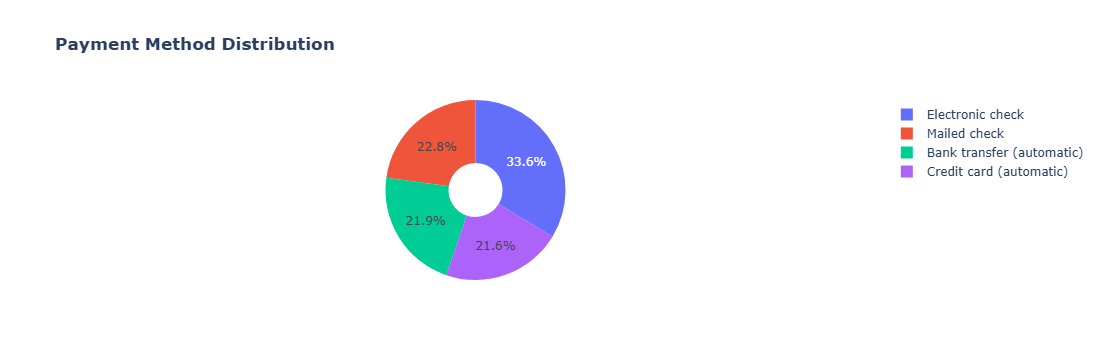

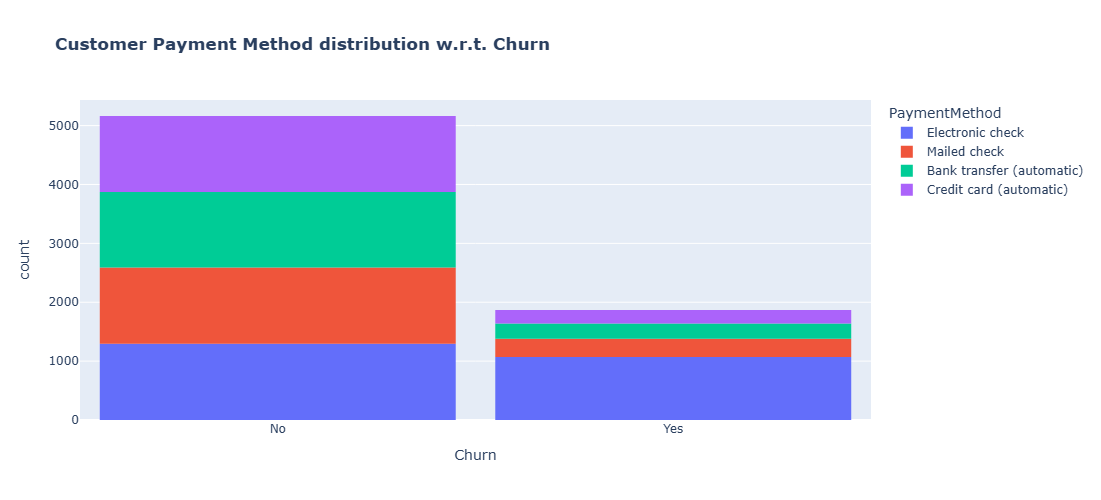

In [49]:
labels = data['PaymentMethod'].unique()
values = data['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()

fig = px.histogram(data, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [51]:
 data[data["gender"]=="Male"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       992
Fiber optic      No       910
No               No       717
Fiber optic      Yes      633
DSL              Yes      240
No               Yes       57
Name: count, dtype: int64

In [53]:
data[data["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

InternetService  Churn
DSL              No       965
Fiber optic      No       889
No               No       690
Fiber optic      Yes      664
DSL              Yes      219
No               Yes       56
Name: count, dtype: int64

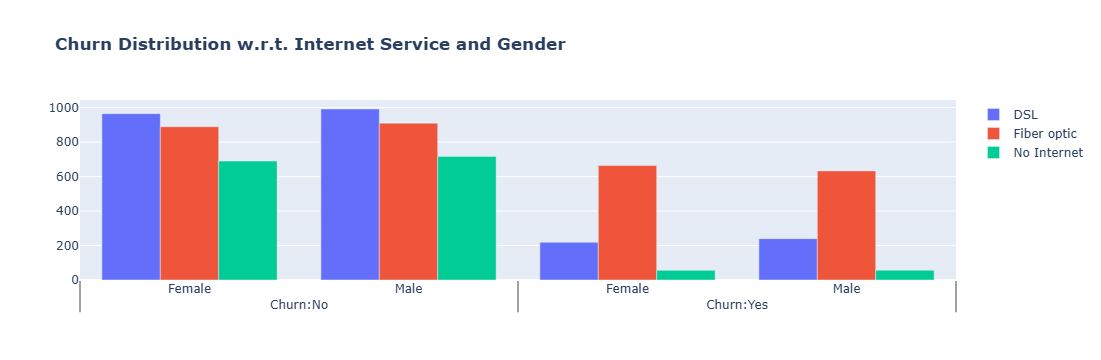

In [55]:

fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

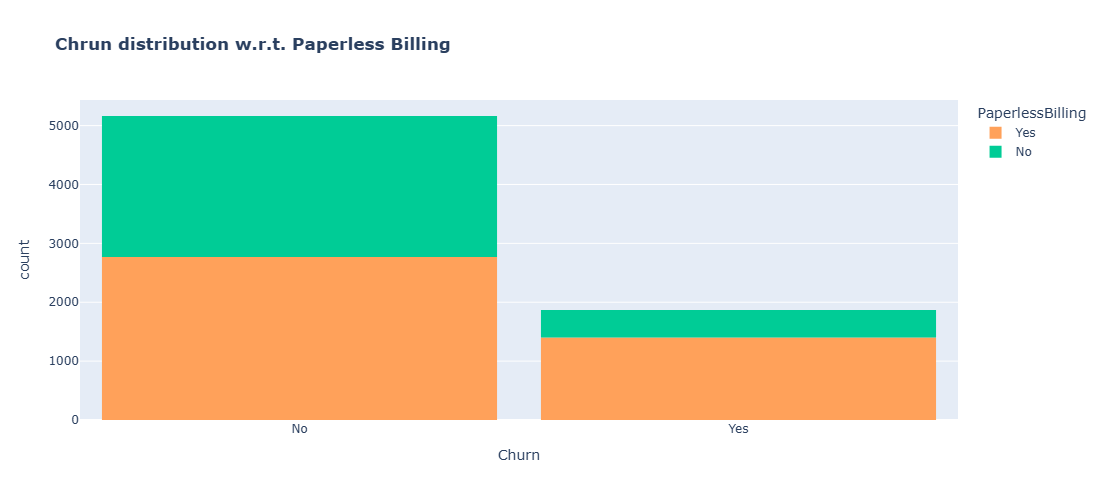

In [57]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(data, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

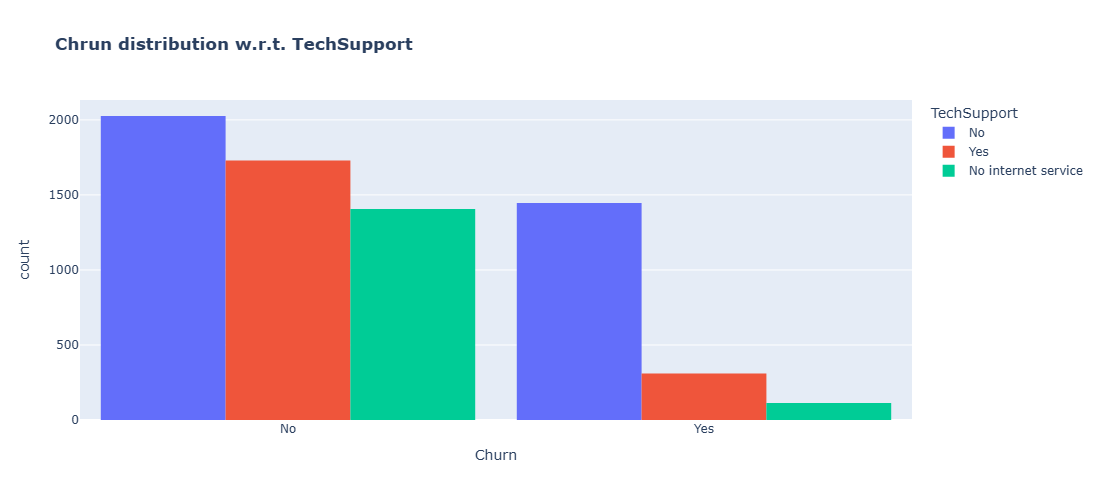

In [59]:
fig = px.histogram(data, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

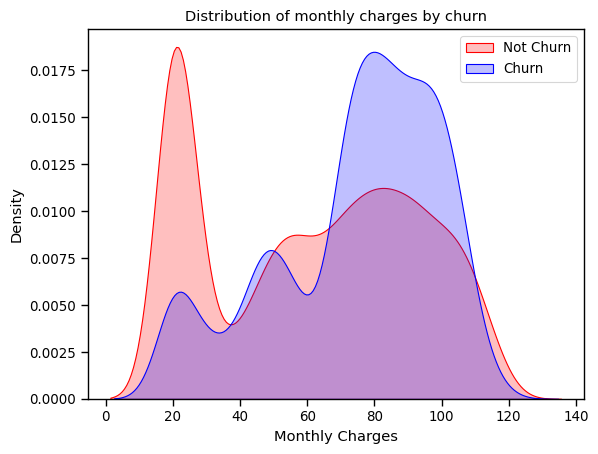

In [61]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

### Customers with higher monthly charges are more likely to churn

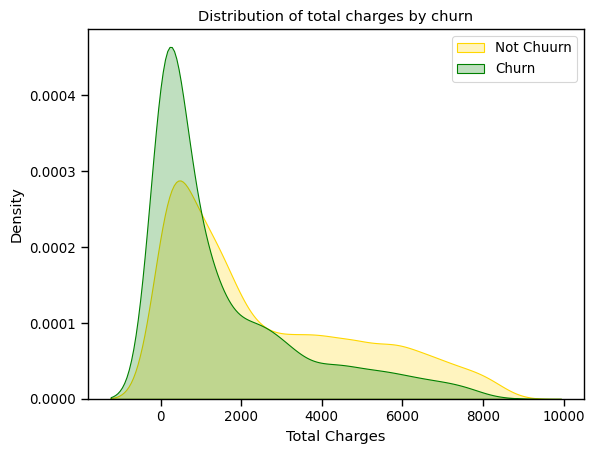

In [64]:
ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(data.TotalCharges[(data["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Not Chuurn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

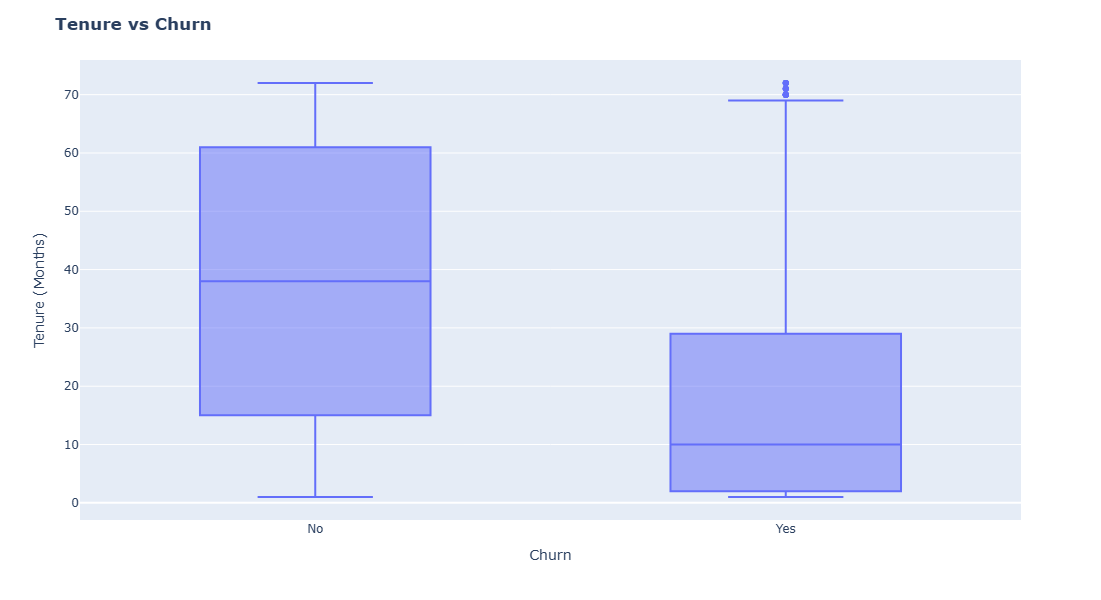

In [66]:
fig = px.box(data, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

New customers are more likely to churn

In [69]:
#Create a label encoder object
le = LabelEncoder()
# Label Encoding will be used for columns with 2 or less unique 
values
le_count = 0
for col in data.columns[1:]:
    if data[col].dtype == 'object':
        if len(list(data[col].unique())) <= 2:
            le.fit(data[col])
            data[col] = le.transform(data[col])
            le_count += 1
print('{} columns were label encoded.'.format(le_count))



3 columns were label encoded.


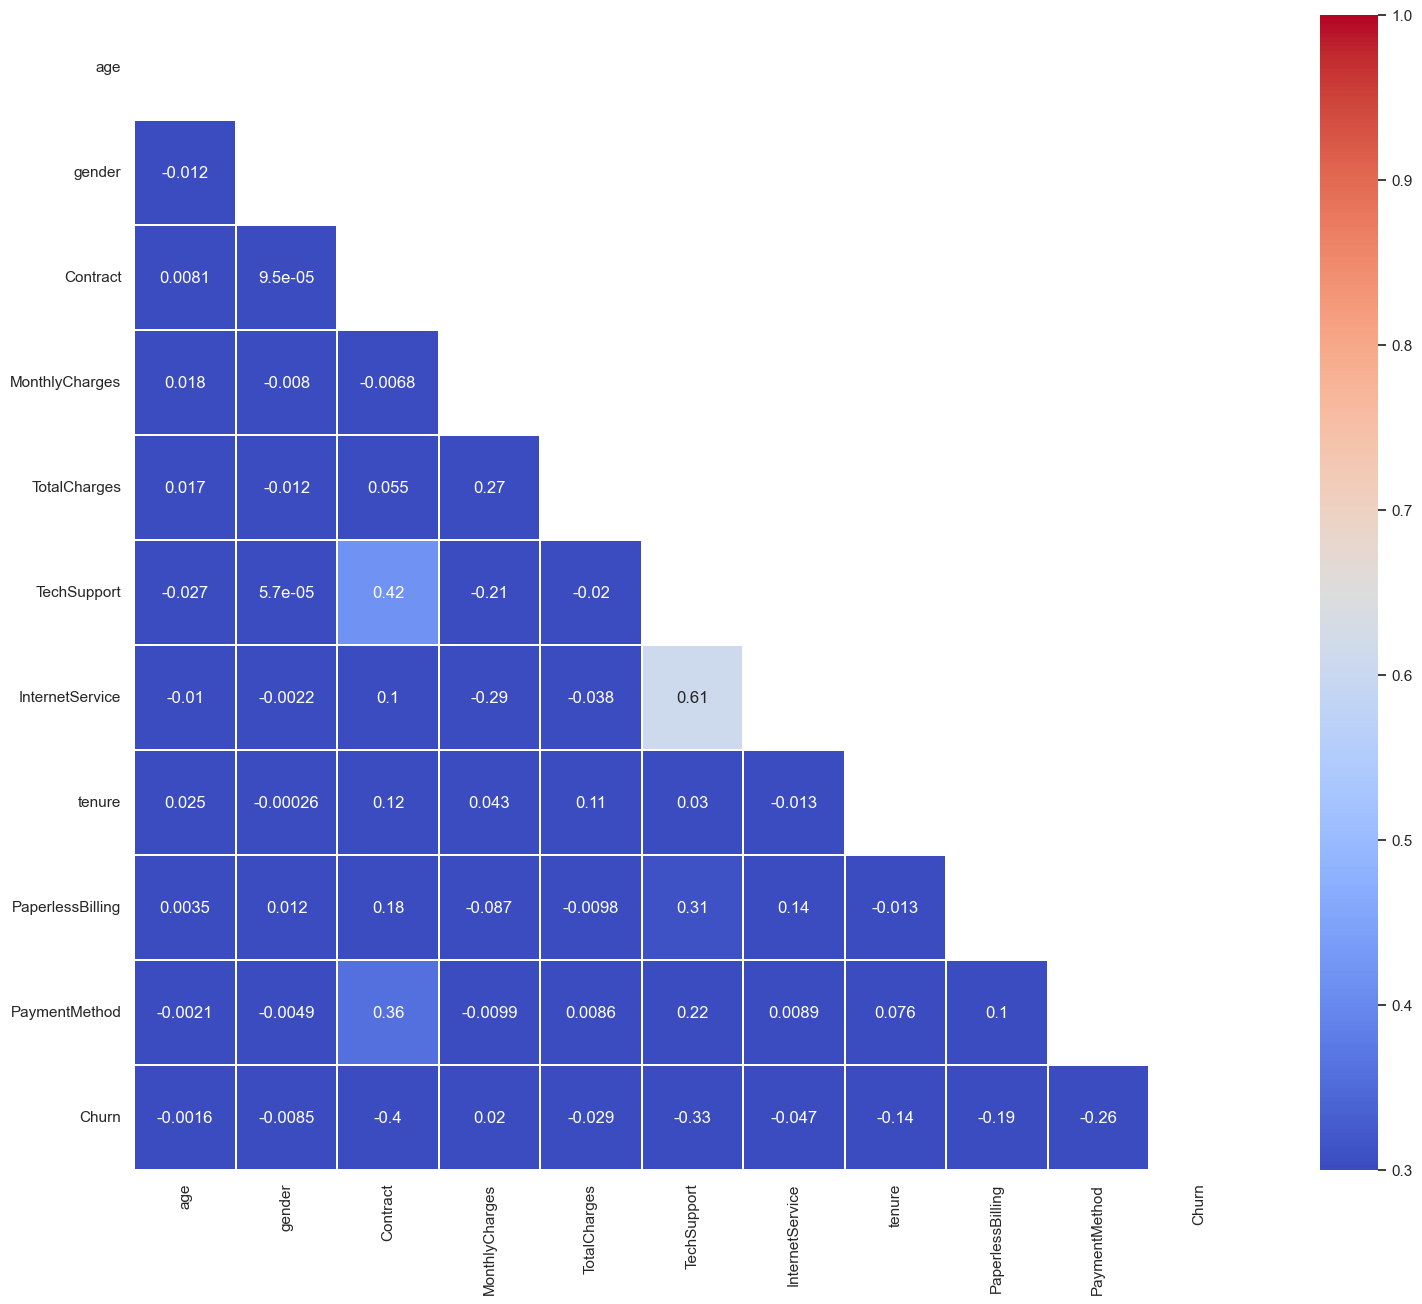

In [71]:
#Set and compute the Correlation Matrix:
sns.set(style="white")
plt.figure(figsize=(18, 15))

corr = data.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=0.3, vmax=1)

### Multicollinearity check using VIF

#TODO:
from statsmodels.stats.outliers_influence import variance_inflation_factor
data_ = pd.read_csv("data.csv")
X = data_[['gender', 'SeniorCitizen', 'Partner', 'Dependents','tenure', 'PhoneService','PaperlessBilling','MonthlyCharges','TotalCharges']]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
  
#calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
  
print(vif_data)

In [75]:
def encode_data(dataframe):
    if dataframe.dtype == "object":
        dataframe = LabelEncoder().fit_transform(dataframe)
    return dataframe

data = data.apply(lambda x: encode_data(x))
data.head()

,age,gender,Contract,MonthlyCharges,TotalCharges,TechSupport,InternetService,tenure,PaperlessBilling,PaymentMethod,Churn
0,26,0,0,29.85,29.85,0,0,1,1,2,0
1,27,1,1,56.95,1889.50,0,0,34,0,3,0
2,19,1,0,53.85,108.15,0,0,2,1,3,1
3,27,1,1,42.30,1840.75,2,0,45,0,0,0
4,22,0,0,70.70,151.65,0,1,2,1,2,1


In [77]:
X = data.drop(columns = "Churn")
y = data["Churn"].values

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 4, stratify =y)

In [81]:
def distplot(feature, frame, color='r'):
    plt.figure(figsize=(8,3))
    plt.title("Distribution for {}".format(feature))
    ax = sns.distplot(frame[feature], color= color)

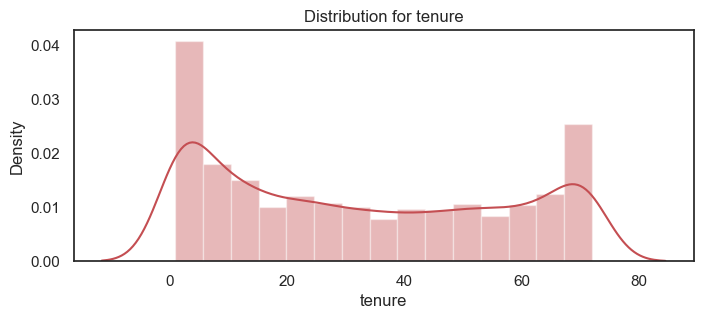

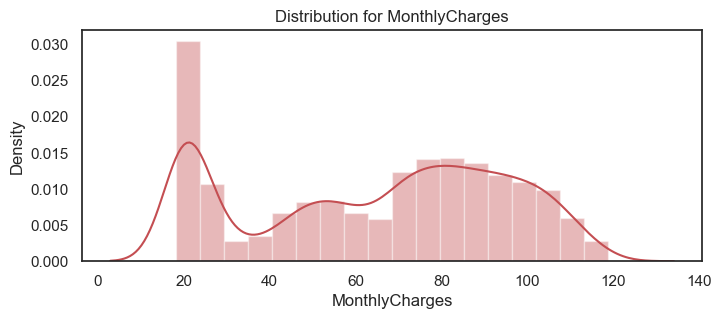

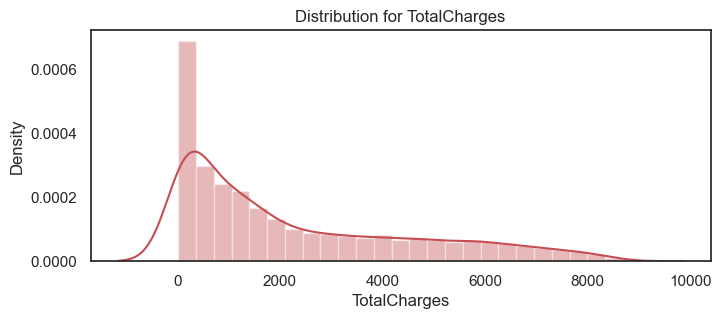

In [83]:
col =  ["tenure", 'MonthlyCharges', 'TotalCharges']
for features in col :distplot(features, data)

The features need standard scaling as all of them are distributed over different range values 

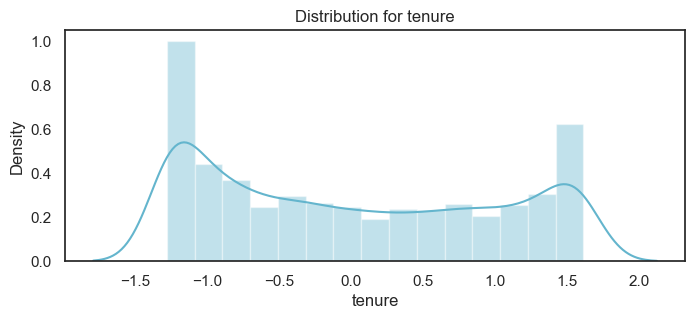

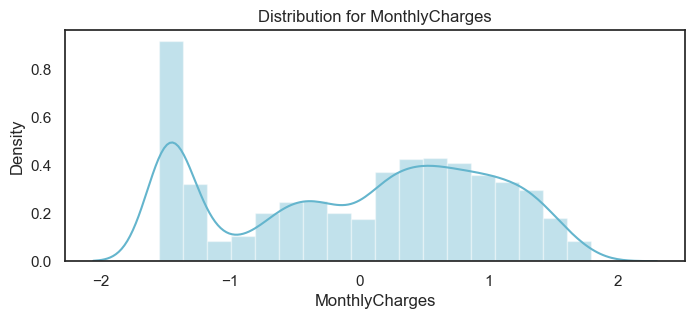

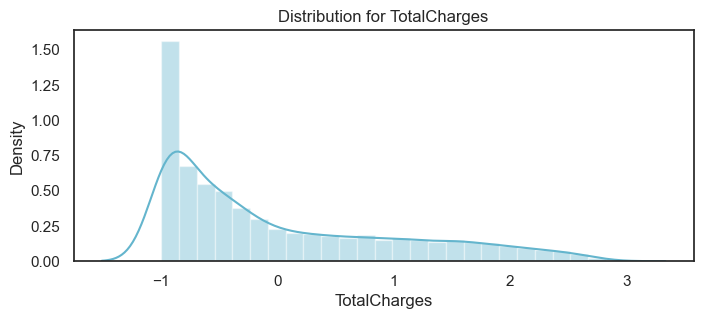

In [86]:
data_std = pd.DataFrame(StandardScaler().fit_transform(data[col]).astype('float64'), columns = col)
for feat in col: distplot(feat, data_std, color='c')

In [88]:
data.columns

Index(['age', 'gender', 'Contract', 'MonthlyCharges', 'TotalCharges',
       'TechSupport', 'InternetService', 'tenure', 'PaperlessBilling',
       'PaymentMethod', 'Churn'],
      dtype='object')

In [90]:
for i in data.columns:
    print(i, ": ", data[i].unique())

age :  [26 27 19 22 20 30 29 23 21 25 28 24]
gender :  [0 1]
Contract :  [0 1 2]
MonthlyCharges :  [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges :  [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
TechSupport :  [0 2 1]
InternetService :  [0 1 2]
tenure :  [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PaperlessBilling :  [1 0]
PaymentMethod :  [2 3 0 1]
Churn :  [0 1]


In [92]:
# Divide the columns into 3 categories, one ofor standardisation, one for label encoding and one for one hot encoding

cat_cols_ohe =['PaymentMethod', 'Contract', 'InternetService'] # those that need one-hot encoding
cat_cols_le = list(set(X_train.columns)- set(col) - set(cat_cols_ohe)) #those that need label encoding

print(cat_cols_le)

['gender', 'TechSupport', 'age', 'PaperlessBilling']


In [94]:
scaler = StandardScaler()
X_train[col] = StandardScaler().fit_transform(X_train[col])
X_test[col] = StandardScaler().fit_transform(X_test[col])

In [96]:
models = []

models.append(('Logistic Regression', LogisticRegression(solver='liblinear', random_state = 0, class_weight='balanced')))
models.append(('SVC', SVC(kernel = 'linear', random_state = 0)))
models.append(('Kernel SVM', SVC(kernel = 'rbf', random_state = 0)))
models.append(('KNN', KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)))
models.append(('Gaussian NB', GaussianNB()))
models.append(('Decision Tree Classifier', DecisionTreeClassifier(criterion = 'entropy', random_state = 0)))
models.append(('Random Forest', RandomForestClassifier(n_estimators=100, criterion = 'entropy', random_state = 0)))
models.append(("Adaboost", AdaBoostClassifier()))
models.append(("Gradient boost classifier", GradientBoostingClassifier()))
models.append(("Voting Classifier",  VotingClassifier(estimators=[('gbc', GradientBoostingClassifier()), 
                                                                  ('lr', LogisticRegression()), ('abc',  AdaBoostClassifier())], voting='soft')))

## Evaluating the model Results

In [99]:
score_array = []

for each in range(1,25):
    knn_loop = KNeighborsClassifier(n_neighbors = each) 
    knn_loop.fit(X_train,y_train)
    score_array.append(knn_loop.score(X_test,y_test))

score_array

[0.7270142180094786,
 0.752132701421801,
 0.7497630331753554,
 0.7691943127962085,
 0.7654028436018957,
 0.7744075829383886,
 0.7772511848341233,
 0.7829383886255924,
 0.7805687203791469,
 0.7819905213270142,
 0.7829383886255924,
 0.7815165876777251,
 0.7834123222748816,
 0.7848341232227488,
 0.7843601895734598,
 0.7890995260663507,
 0.7838862559241706,
 0.7919431279620853,
 0.7881516587677725,
 0.7924170616113744,
 0.7919431279620853,
 0.7938388625592417,
 0.7914691943127962,
 0.790521327014218]

## KNN

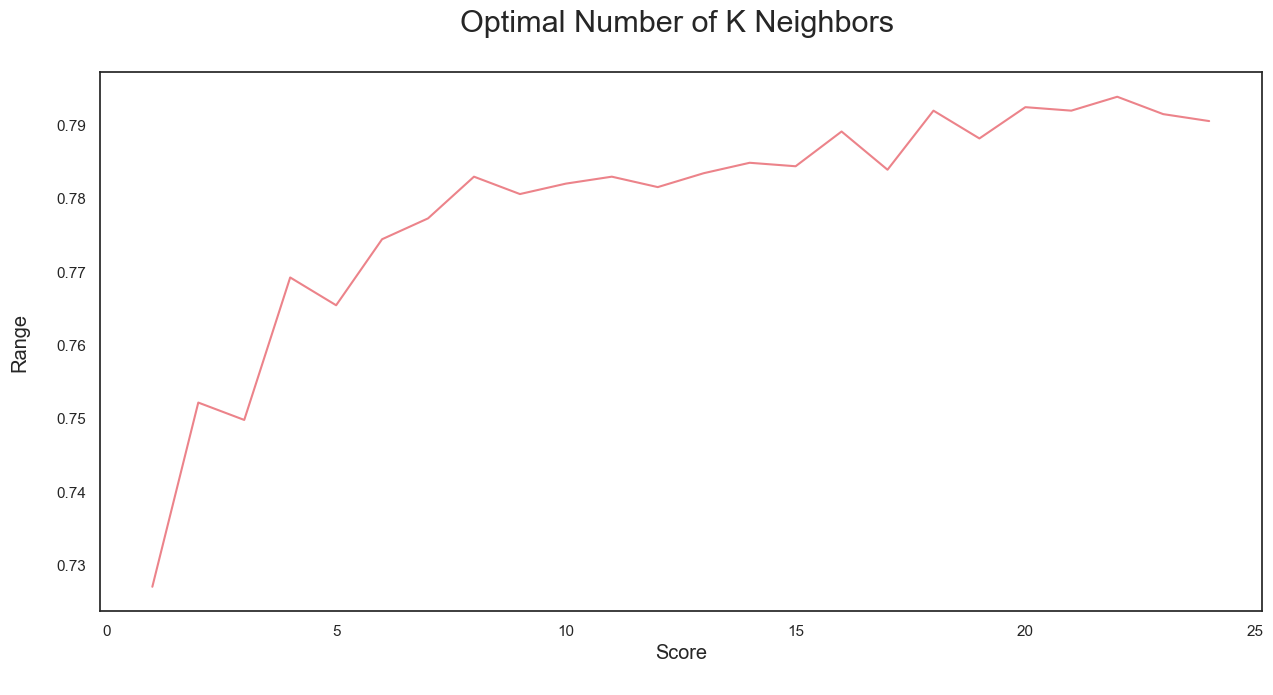

In [102]:
fig = plt.figure(figsize=(15, 7))
plt.plot(range(1,25),score_array, color = '#ec838a')
plt.ylabel('Range\n',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
plt.xlabel('Score\n',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")

plt.title('Optimal Number of K Neighbors \n',horizontalalignment="center", fontstyle = "normal",fontsize = "22", fontfamily = "sans-serif")
#plt.legend(loc='top right', fontsize = "medium")

plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.show()

## Random Forest

In [107]:
score_array = []
for each in range(1,100):
    rf_loop = RandomForestClassifier(n_estimators = each, random_state = 1) 
    rf_loop.fit(X_train,y_train)
    score_array.append(rf_loop.score(X_test,y_test))
    


In [110]:
for i,j in enumerate(score_array):
    print(i+1,":",j)

1 : 0.7492890995260664
2 : 0.7672985781990521
3 : 0.7568720379146919
4 : 0.7739336492890996
5 : 0.7630331753554502
6 : 0.771090047393365
7 : 0.7744075829383886
8 : 0.7796208530805687
9 : 0.7786729857819905
10 : 0.7834123222748816
11 : 0.7796208530805687
12 : 0.7848341232227488
13 : 0.7786729857819905
14 : 0.7819905213270142
15 : 0.7786729857819905
16 : 0.7815165876777251
17 : 0.7800947867298578
18 : 0.7815165876777251
19 : 0.7843601895734598
20 : 0.7829383886255924
21 : 0.7819905213270142
22 : 0.7796208530805687
23 : 0.7777251184834123
24 : 0.7805687203791469
25 : 0.7772511848341233
26 : 0.7824644549763033
27 : 0.7786729857819905
28 : 0.7786729857819905
29 : 0.7777251184834123
30 : 0.7815165876777251
31 : 0.7791469194312797
32 : 0.7796208530805687
33 : 0.7781990521327015
34 : 0.7772511848341233
35 : 0.7781990521327015
36 : 0.776303317535545
37 : 0.7767772511848341
38 : 0.7772511848341233
39 : 0.7800947867298578
40 : 0.7796208530805687
41 : 0.7791469194312797
42 : 0.7781990521327015
43 

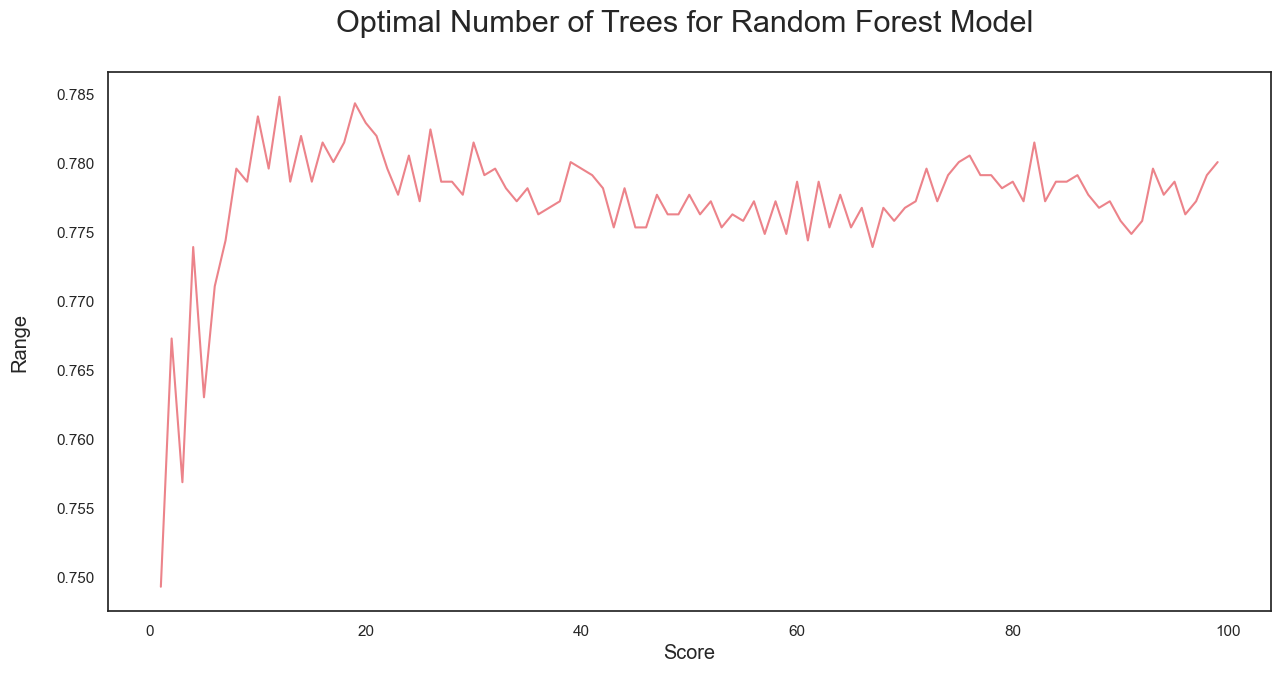

In [114]:
fig = plt.figure(figsize=(15, 7))
plt.plot(range(1,100),score_array, color = '#ec838a')
plt.ylabel('Range\n',horizontalalignment="center",
fontstyle = "normal", fontsize = "large", 
fontfamily = "sans-serif")
plt.xlabel('Score\n',horizontalalignment="center",
fontstyle = "normal", fontsize = "large", 
fontfamily = "sans-serif")
plt.title('Optimal Number of Trees for Random Forest Model \n',horizontalalignment="center", fontstyle = "normal", fontsize = "22",
          fontfamily = "sans-serif")
#plt.legend(loc='top right', fontsize = "medium")
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")
plt.show()

## 2nd Iteration

In [7]:
#evaluation of results
def model_evaluation(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    f2 = fbeta_score(y_test, y_pred, beta = 2.0)

    results = pd.DataFrame([[model_name, acc, prec, rec, f1, f2]], 
                       columns = ["Model", "Accuracy", "Precision", "Recall", "F1 SCore", "F2 Score"])
    results = results.sort_values(["Precision", "Recall", "F2 Score"], ascending = False)
    return results

In [119]:
# Logistic regression
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

#SVC

classifier2 = SVC(kernel = 'linear', random_state = 0)
classifier2.fit(X_train, y_train)
y_pred2 = classifier2.predict(X_test)

#knn

classifier3 = KNeighborsClassifier(n_neighbors=22, metric="minkowski", p=2)
classifier3.fit(X_train, y_train)
y_pred3 = classifier3.predict(X_test)


#Kernel SVM
classifier4 = SVC(kernel="rbf", random_state =0)
classifier4.fit(X_train, y_train)
y_pred4 = classifier4.predict(X_test)


#Naive Bayes
classifier5 = GaussianNB()
classifier5.fit(X_train, y_train)
y_pred5 = classifier5.predict(X_test)

#Decision tree
classifier6 = DecisionTreeClassifier(criterion="entropy", random_state=0)
classifier6.fit(X_train, y_train)
y_pred6 = classifier6.predict(X_test)

#Random Forest

classifier7 = RandomForestClassifier(n_estimators=72, criterion="entropy", random_state=0)
classifier7.fit(X_train, y_train)
y_pred7 = classifier7.predict(X_test)

#Adaboost
classifier8 = AdaBoostClassifier()
classifier8.fit(X_train, y_train)
y_pred8 = classifier8.predict(X_test)

#Gradient Boost
classifier9 = GradientBoostingClassifier()


classifier9.fit(X_train, y_train)
y_pred9 = classifier9.predict(X_test)





#Voting Classifier

classifier10 = VotingClassifier(estimators=[('gbc', GradientBoostingClassifier()), ('lr', LogisticRegression()),
                                            ('abc', AdaBoostClassifier())], voting='soft')



classifier10.fit(X_train, y_train)
y_pred10 = classifier10.predict(X_test)

In [120]:
lr = model_evaluation(y_test, y_pred, "Logistic Regression")
svm = model_evaluation(y_test, y_pred2, "SVM (Linear)")
knn = model_evaluation(y_test, y_pred3, "K-Nearest Neighbours")
k_svm = model_evaluation(y_test, y_pred4, "Kernel SVM")
nb = model_evaluation(y_test, y_pred5, "Naive Bayes")
dt = model_evaluation(y_test, y_pred6, "Decision Tree")
rf = model_evaluation(y_test, y_pred7, "Random Forest")
ab = model_evaluation(y_test, y_pred8, "Adaboost")
gb = model_evaluation(y_test, y_pred9, "Gradient Boost")
vc = model_evaluation(y_test, y_pred10, "Voting Classifier")

<b>k-Fold Cross-Validation</b>: Model evaluation is most commonly done through ‘K- fold Cross-Validation’ technique that primarily helps us to fix the variance. Variance problem occurs when we get good accuracy while running the model on a training set and a test set but then the accuracy looks different when the model is run on another test set.
So, in order to fix the variance problem, k-fold cross-validation basically split the training set into 10 folds and train the model on 9 folds (9 subsets of the training dataset) before testing it on the test fold. This gives us the flexibility to train our model on all ten combinations of 9 folds; giving ample room to finalize the variance.

In [124]:
#TODO: Model Evaluation

In [126]:
def k_fold_cross_validation(classifier_name, name):
    accuracies = cross_val_score(estimator=classifier_name,
                            X=X_train, y=y_train, cv =10)
    print(name, "accuracy: %0.2f (+/- %0.2f)"  % (accuracies.mean(), accuracies.std() * 2))

In [128]:
k_fold_cross_validation(classifier8, "Adaboost")


Adaboost accuracy: 0.79 (+/- 0.03)


In [130]:
k_fold_cross_validation(classifier10, "Voting classifier")

Voting classifier accuracy: 0.80 (+/- 0.03)


In [131]:
k_fold_cross_validation(classifier9, "Gradient Boost classifier")

Gradient Boost classifier accuracy: 0.80 (+/- 0.03)


In [134]:
k_fold_cross_validation(classifier, "Logistic regression")

Logistic regression accuracy: 0.79 (+/- 0.04)


In [136]:
k_fold_cross_validation(classifier4, "Kernel SVM")

Kernel SVM accuracy: 0.78 (+/- 0.02)


In [138]:
# ROC Curve

def ROC_curve(classifier_, name, y_pred_):
    classifier_.fit(X_train, y_train) 
    probs = classifier_.predict_proba(X_test) 
    probs = probs[:, 1] 
    classifier_roc_auc = roc_auc_score(y_test, probs )
    rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, classifier_.predict_proba(X_test)[:,1])
    plt.figure(figsize=(14, 6))

    label_ = name + '(area = %0.2f)' % classifier_roc_auc
    # Plot Adaboost ROC
    plt.plot(rf_fpr, rf_tpr, 
    label=label_)
    # Plot Base Rate ROC
    plt.plot([0,1], [0,1],label='Base Rate' 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.ylabel('True Positive Rate \n',horizontalalignment="center",
    fontstyle = "normal", fontsize = "medium", 
    fontfamily = "sans-serif")

    plt.xlabel('\nFalse Positive Rate \n',horizontalalignment="center",
    fontstyle = "normal", fontsize = "medium", 
    fontfamily = "sans-serif")

    plt.title('ROC Graph \n',horizontalalignment="center", 
    fontstyle = "normal", fontsize = "22", 
    fontfamily = "sans-serif")

    plt.legend(loc="lower right", fontsize = "medium")
    plt.xticks(rotation=0, horizontalalignment="center")
    plt.yticks(rotation=0, horizontalalignment="right")
    plt.show()
    
  

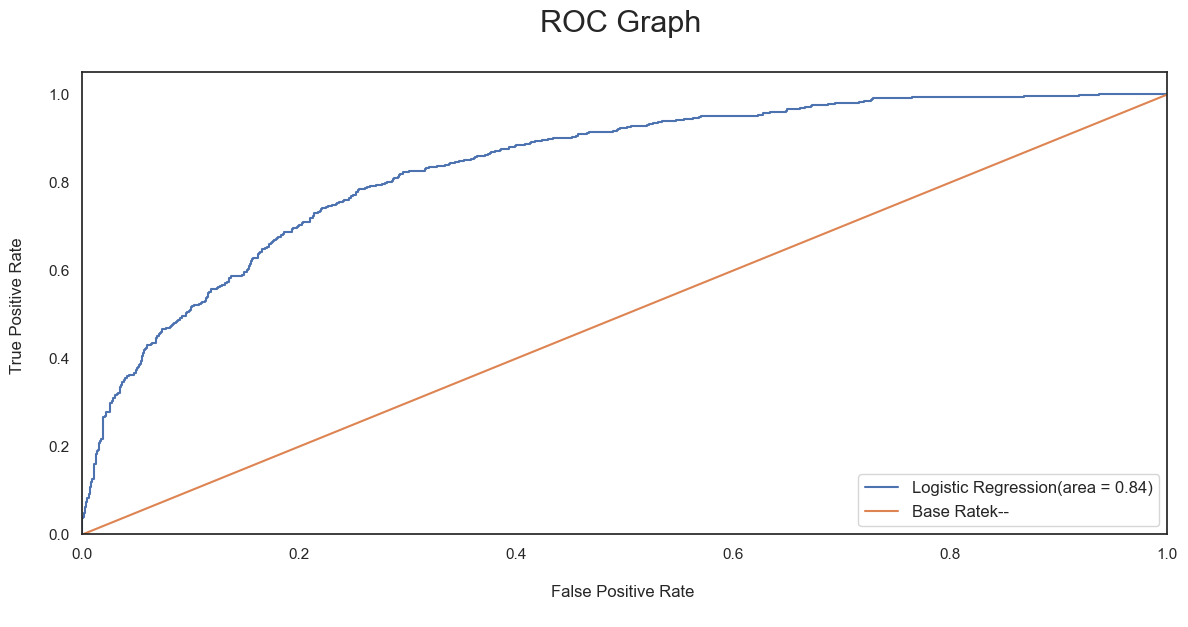

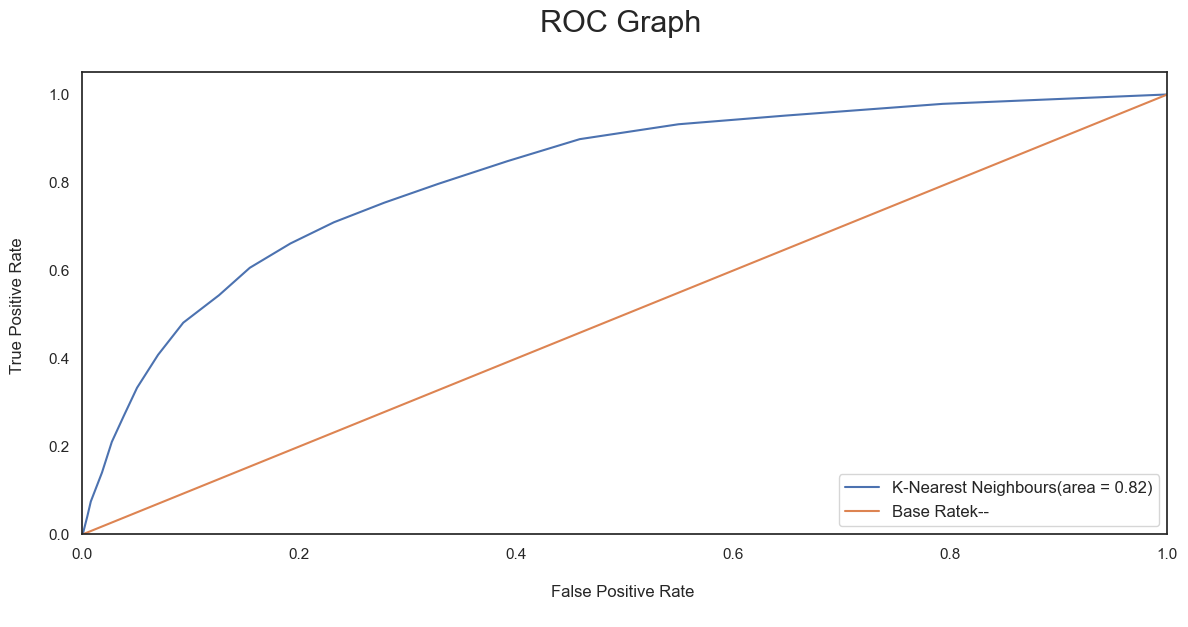

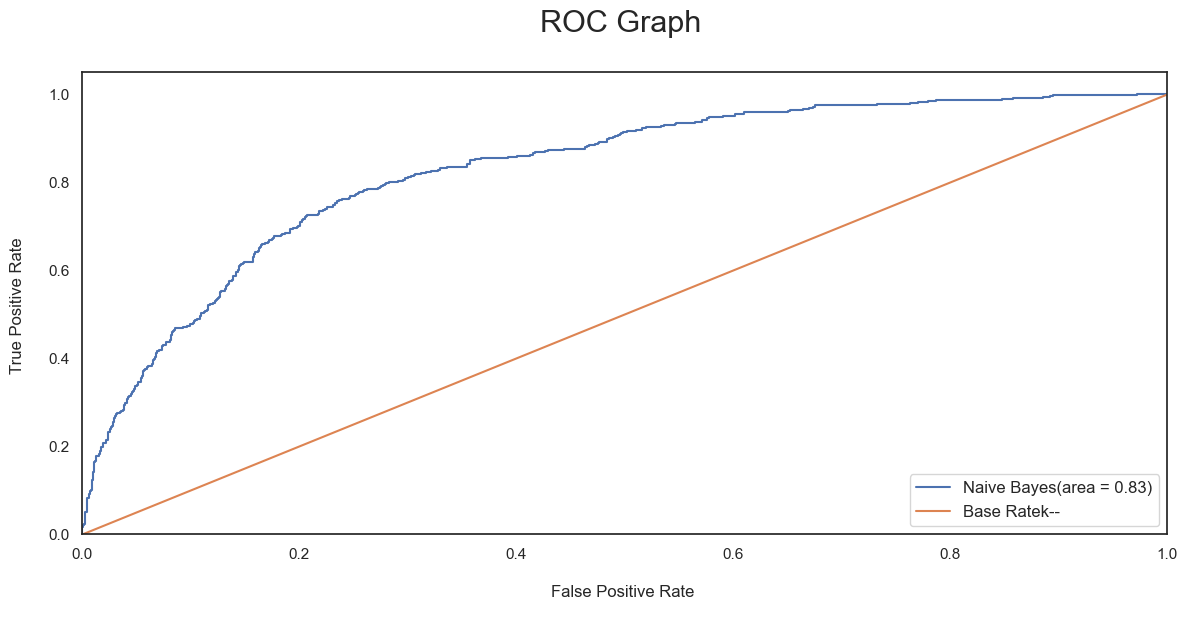

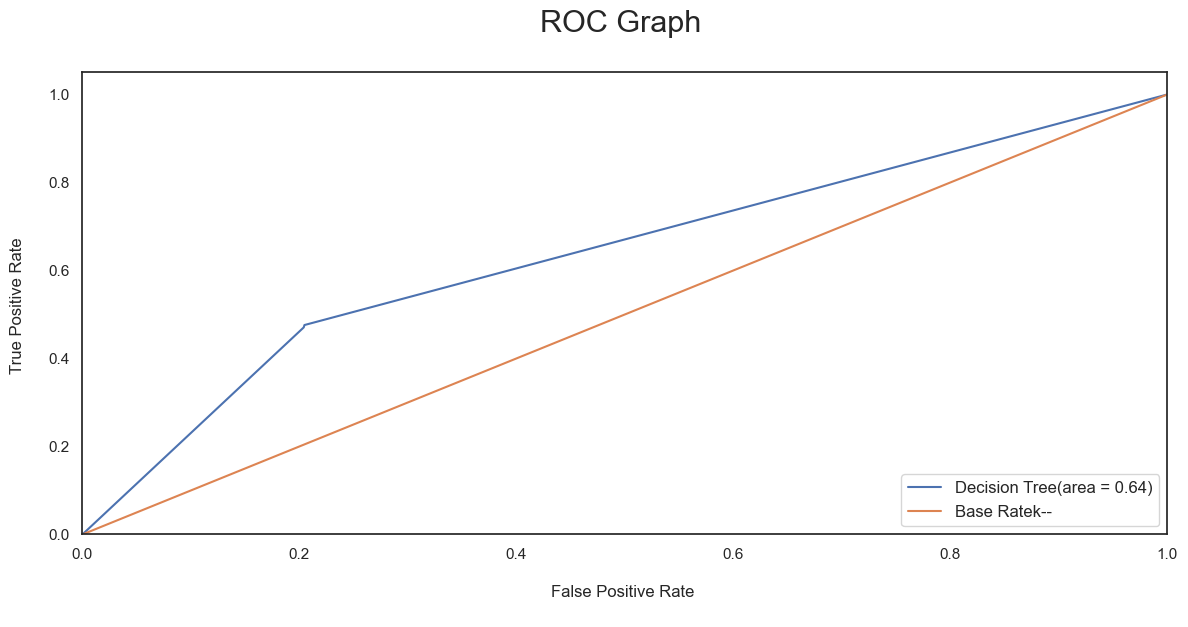

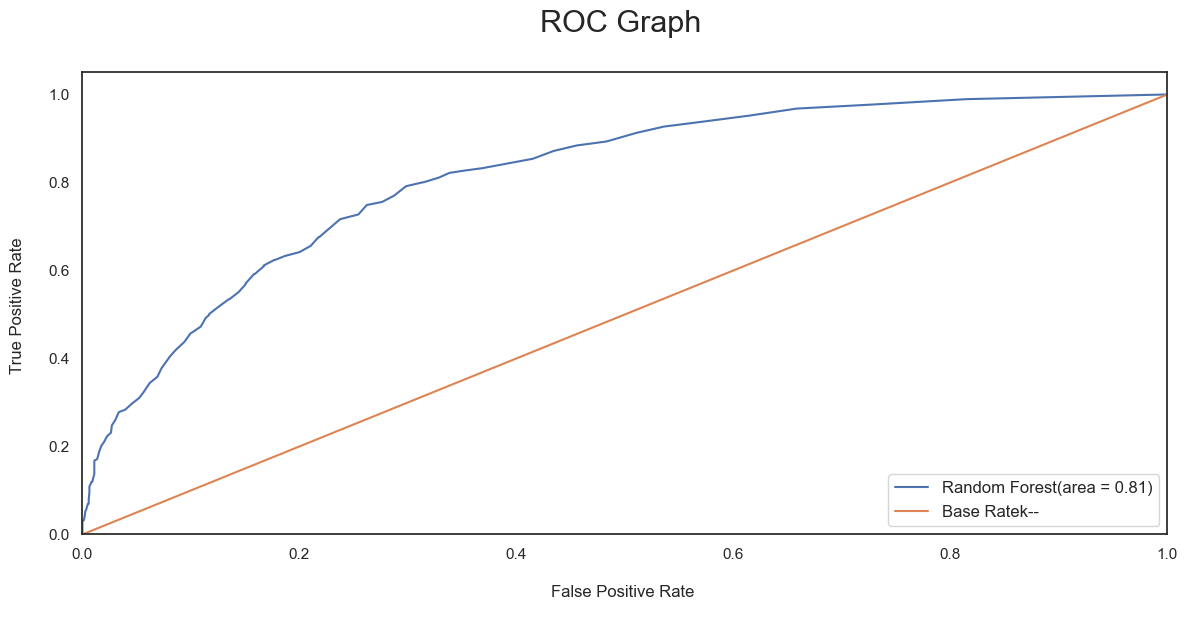

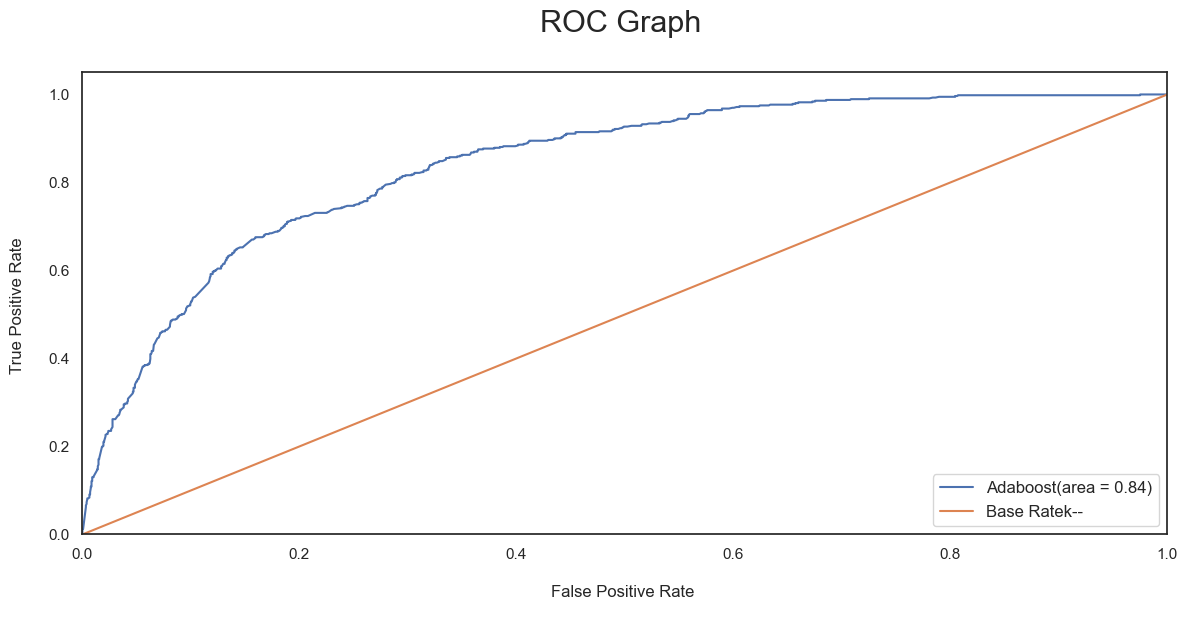

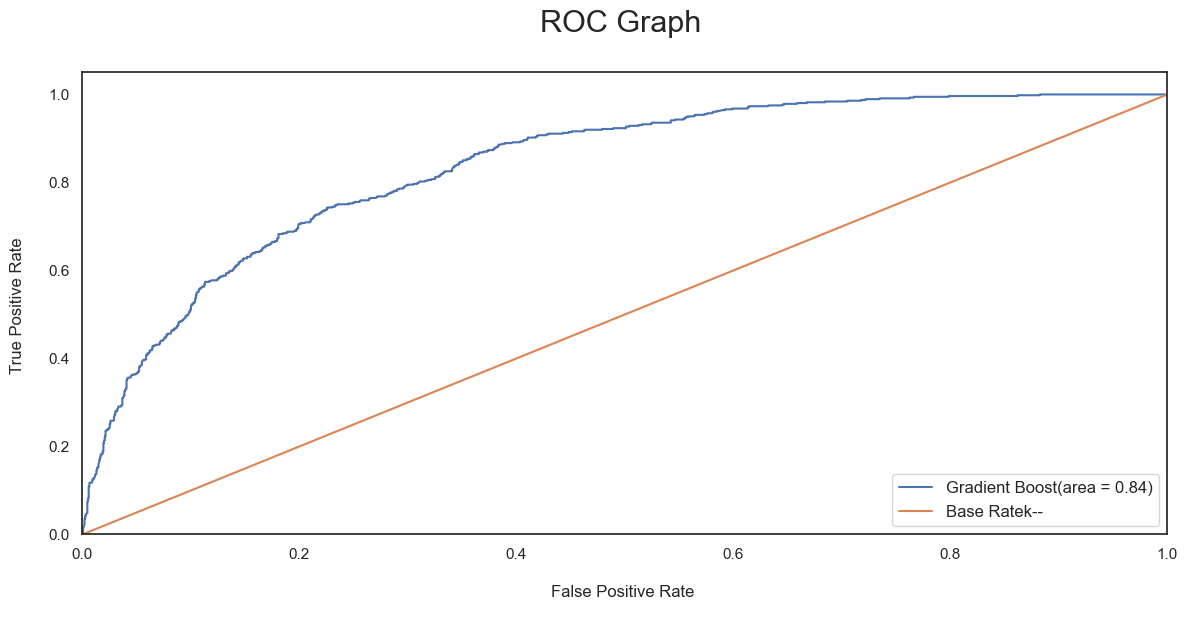

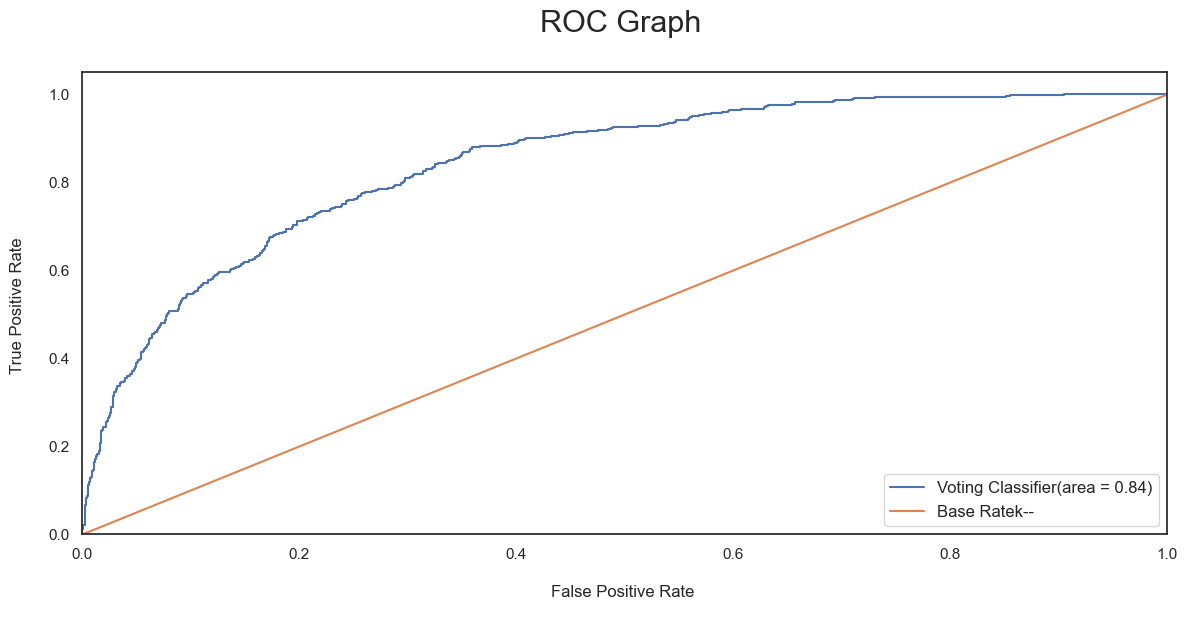

In [142]:
preds = [y_pred, y_pred3,  y_pred5, y_pred6, y_pred7,
              y_pred8, y_pred9, y_pred10]
classifiers = [classifier , classifier3, classifier5, classifier6, classifier7,
             classifier8, classifier9, classifier10]
model_names_ = ["Logistic Regression",  "K-Nearest Neighbours","Naive Bayes",
               "Decision Tree", "Random Forest", "Adaboost", "Gradient Boost",  "Voting Classifier"]

for i, j, k in zip(classifiers, model_names_, preds):
    ROC_curve(i, j, k) 

In [144]:
# Cross validation

from sklearn.model_selection import cross_val_score

# Function that will track the mean value and the standard deviation of the accuracy
def cvDictGen(functions, scr, X_train = X, y_train = y, cv = 5):
    cvDict = {}
    for func in functions:
        cvScore = cross_val_score(func, X_train, y_train, cv = cv, scoring = scr)
        cvDict[str(func).split('(')[0]] = [cvScore.mean(), cvScore.std()]
    
    return cvDict

In [146]:
cvD = cvDictGen(classifiers, scr = 'roc_auc')
cvD

{'LogisticRegression': [0.8341453245648708, 0.011234456051251703],
 'KNeighborsClassifier': [0.7897990631635257, 0.008052627071194038],
 'GaussianNB': [0.8235867325646383, 0.009128691519254805],
 'DecisionTreeClassifier': [0.6495716942485583, 0.013648869364097423],
 'RandomForestClassifier': [0.8181588144809258, 0.016324377523239134],
 'AdaBoostClassifier': [0.841130643812136, 0.01265082540562278],
 'GradientBoostingClassifier': [0.8415526300469576, 0.012442010934140291],
 'VotingClassifier': [0.8424072182874495, 0.012170794024854542]}

## Predicting feature importance

In [149]:
# Gradient Boost
feature_importances = pd.concat([pd.DataFrame(data.columns, columns = ["features"]),
                                 pd.DataFrame(np.transpose(classifier9.feature_importances_), columns = ["coef"])],axis = 1)
feature_importances.sort_values(by = "coef", ascending = False)

,features,coef
2,Contract,0.430132
3,MonthlyCharges,0.170142
7,tenure,0.150918
4,TotalCharges,0.126552
5,TechSupport,0.071851
9,PaymentMethod,0.016321
6,InternetService,0.013535
8,PaperlessBilling,0.011564
0,age,0.007006
1,gender,0.001978


In [151]:
# Ada boost classifier
feature_importances = pd.concat([pd.DataFrame(data.columns, columns = ["features"]),
                                 pd.DataFrame(np.transpose(classifier8.feature_importances_), columns = ["coef"])],axis = 1)
feature_importances.sort_values(by = "coef", ascending = False)

,features,coef
4,TotalCharges,0.36
3,MonthlyCharges,0.16
7,tenure,0.16
2,Contract,0.12
0,age,0.06
9,PaymentMethod,0.06
6,InternetService,0.04
5,TechSupport,0.02
8,PaperlessBilling,0.02
1,gender,0.00


## Hyper Parameter tuning

## Using Randomized search CV

In [157]:
#Ada boost

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
adaHyperParams = {'n_estimators': [10,50,100,200,420], "learning_rate":  [0.001, 0.01, 0.1, 0.3]}
gridSearchAda = RandomizedSearchCV(estimator = classifier8, param_distributions = adaHyperParams, n_iter = 5,
                                   scoring = 'roc_auc') # other option accuracy
gridSearchAda.fit(X_train, y_train)

RandomizedSearchCV(estimator=AdaBoostClassifier(), n_iter=5,
                   param_distributions={'learning_rate': [0.001, 0.01, 0.1,
                                                          0.3],
                                        'n_estimators': [10, 50, 100, 200,
                                                         420]},
                   scoring='roc_auc')

In [139]:
gridSearchAda.best_params_, gridSearchAda.best_score_

({'n_estimators': 200, 'learning_rate': 0.3}, 0.8397733928069595)

In [141]:
bestAdaModFitted = gridSearchAda.best_estimator_.fit(X_train, y_train)

In [143]:
# Getting the score AdaBoost
test_labels = bestAdaModFitted.predict_proba(np.array(X_test.values))[:,1]
roc_auc_score(y_test,test_labels , average = 'macro', sample_weight = None)

0.8308471108379968

### Gradient Boost

In [146]:
gbHyperParams = {'loss' : ['deviance', 'exponential'],
                 'n_estimators': randint(10, 500),
                 'max_depth': randint(1,10)}
# Initialization
gridSearchGB = RandomizedSearchCV(estimator = classifier9, param_distributions = gbHyperParams, n_iter = 10,
                                   scoring = 'roc_auc')
# Fitting the model
gridSearchGB.fit(X_train, y_train)

RandomizedSearchCV(estimator=GradientBoostingClassifier(),
                   param_distributions={'loss': ['deviance', 'exponential'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000262F7664830>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000262F77918E0>},
                   scoring='roc_auc')

In [148]:
gridSearchGB.best_params_, gridSearchGB.best_score_

({'loss': 'exponential', 'max_depth': 5, 'n_estimators': 49},
 0.8413184093276321)

In [150]:
bestGBModFitted = gridSearchGB.best_estimator_.fit(X_train, y_train)

In [152]:
# Getting the score AdaBoost
test_labels_GB = bestGBModFitted.predict_proba(np.array(X_test.values))[:,1]
roc_auc_score(y_test,test_labels_GB , average = 'macro', sample_weight = None)

0.8374881615302381

## Using Grid SearchCV

In [155]:
ABC = AdaBoostClassifier()

ABC_param_grid = {"n_estimators" :[10,50,100,200,420],
                  "learning_rate":  [0.001, 0.01, 0.1, 0.3]}

gsABC = GridSearchCV(ABC, param_grid = ABC_param_grid, cv = 10, scoring = "roc_auc", n_jobs = 6, verbose = 1)

gsABC.fit(X_train,y_train)

ada_best = gsABC.best_estimator_
print(ada_best)
print(gsABC.best_score_)


Fitting 10 folds for each of 20 candidates, totalling 200 fits
AdaBoostClassifier(learning_rate=0.1, n_estimators=200)
0.8440548164310735


In [156]:
bestAdaModFitted2 = gsABC.best_estimator_.fit(X_train, y_train)

In [157]:
test_labels = bestAdaModFitted2.predict_proba(np.array(X_test.values))[:,1]
roc_auc_score(y_test,test_labels , average = 'macro', sample_weight = None)

0.8431291995640912